Welcome to my Notebook! Each section/step is firstly done by code, followed by a text cell that answers the rubrics for that step, more in-detail than the comments in the code, if necessary, to fulfill the rubric properly.

Where AI was used either for the comments and code, it is duly referenced.

GitHub repository: https://github.com/Faris225883/ML-fundamentals-2026
Notebook: assignment_1_faris_selimovic.ipynb

The notebook was tested several times and it runs without issue!

# 1. Identifying the Prediction Target
First, let's load all necessary libraries and inspect the dataset.  



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import OrdinalEncoder
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
df = pd.read_csv("bank-additional.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [2]:
#hence...
X = df.drop("y", axis=1)
y = df["y"]

The prediction variable is 'y' or yes, whether the client accepted the offer or not. This is a 0/1 (logistic) outcome of a marketing campaign of the dataset. In the end, it is the outcome that is most important and we want to see as 'yes', which would mean our campaign worked for that customer (type).

"When it comes to other potential target variables, options could be the 'campaign' column. Why? Because superficially it sounds like the result of the campaign at first, but actually it is just an operating variable of the marketing process, not the final outcome.

A second potential incorrect target variable would be 'poutcome', the previous outcome. Technically, it is an outcome variable but at the wrong time. It is an important variable to measure whether the final outcome will be 'yes', but definitely not the target variable."

NOTE on AI use for this part: The text in this text cell was not just generated by AI and copy-pasted, it was paraphrased, and generated in Bosnian, my mother tongue.

This text was generated (partially) by [AI
ChatGPT 5.2 Thinking]. The prompt used: What would be other potential target variables be incorrectly identified as such and why? (translated from Bosnian, original: Koje bi se druge varijable mogle pogrešno smatrati potencijalnim ciljnim  varijablama i zašto? )

#2. Task Ordering

The correct ordering for this task is as follows, followed by the justification for each step:

1) Identifying the Prediction Target (given)-here the information used is the dataset's structure, and its information, and based on that chose the most apporpriate outcome (target variable 'y').

It is not allowed to choose a target that would yield a better result or use variables that are known after the outcome, like 'duration'.

The leakage risks would be using the incorrect goal or a goal that uses future information, before we start anything.

2) Task Ordering-after we have defined the target variable, we use that as a basis of how to proceed and build our model around that target, which is this step. In its nature, this is a sort of like pre-step, not necessarily a part of processing the data in the pipeline. We also need to keep in mind that we need to split the data before fitting anything, all transformations are done on train.

We must not do any transformations based on descriptive statistics, like mean/median/mode etc. also other things like feature selection, resampling etc on the entire dataset.

The leakage risk would be fitting the model that is preprocessed on the WHOLE dataset, meaning info leaks into training and the end results are too.

3) Data Loading and Exploration-we use information like the data shape, descriptive statistics and columns/rows structure to see all of our information at one glance, to identify discrepancies and potential issues with the data like outliers, data types and more, before taking other appropriate steps, and segregating variables to categorical and numerical accordingly.

At this step, we must not make decisions based on solely the performance of the data at this step.

A leakage risk would be indirect here, using information from the test/validation sets, like target labels or distribution to decide preprocessing choices like dropping features or  before the model is evaluated.

4) Managing Missing Values-here we use the information obtained beforehand, but take it a step further, focusing on exclusively the missingness of the data, its potential cause, extent and whether to remove a variable for the model to be better or impute and how to impute it, based on its nature. Essentially, mapping the missingness.

What is not allowed in this step is do imputation before the split, which learns the statistics that are missing on the whole dataset.

Leakage here could occur if we calculate the median or mode on the full data, and it would affect the imputation, giving overly optimistic results.

5) Feature Selection-in this part we use the information about how correlated the variables are between themselves and what is the threshold where they are too correlated and hence are deemed to increase model complexity without enhancing accuracy and also be a potential for leakage.

Here it is not allowed to do statistics on the WHOLE dataset and THEN choose features.

Hence, a leakage risk would be selection bias, where the statistical tests would influence the choice (selection) of the variables (features). Like computting correlation on y with the full data.

6) Encoding Categorical Variables-in this part we use the information about the basis of the categorical variables and what is their nature, nominal or ordinal. We would take any ordinal variable and encode it according to the order of (education in this case). Same goes for the numerical and regular nominal categorical variables, where we would split them into pipes, for them to be apporpriately applied to the INITAL training and test set, and transform those sets appropriately.

We cannot fit encoders on the whole dataset, as it learns the categories and it should not to give good results, as that is the model kind of cheating.

Hence, when it comes to leakage that cheating of the model I said was the model seeing the categories when it should not, reducing error below actual levels.

7) Data Splitting-in this part we take the information obtained in the last step, and based on it chose the appropriate splitting method of the data into the actual train and test splits. The split MUST happen before any transformations that require fitting/learning parameters. In the steps 3-6 you can do analysis and decision-making, but you cannot fit anything before a split is done. Also, a stratified split is appropriate based on potential class imbalance issue, to save the relationship between them.

It is not allowed to split the data after fitting an encoder in scaling, which is the next step.

Leakage here would mean the train-only parameters become contaminated with information from the split.

8) Feature Scaling-here we take the train/test split we made and use the data used in the split and normalize it, i.e. make it all have the same range and same influence onto the model. We can fit it only on the training set.

It is not allowed to do it on train and test on the full dataset.

The tests here could have an influence on the distribution, affecting the mean or standard deviation, because of the scaling/normalization.

9) Adressing Class Imbalance-here we take the information again from the train/test split of certain groups and try to balance it out in the model to have a more realistic influence of all the possible outcomes put in to the model on the train set.

We cannot do resampling to fix imbalance before the split.

This would lead to leakage by giving duplicated samples, giving unrealistically good results.

10) Training a Logistic Regression Model-in this step, we use all the previous information obtained in the steps beforehand, summarize it, see what it tells us and based on what it tells us, adjust our model's parameters and features accordingly. After we do that, we take the model and test its accuracy and quality in the relevant spheres of modelling. We can use the train only again.

We cannot use the results of the tests in this part to readjust the pipeline to improve our results.

The leakage here wou ld be that the final test metrics would not be fair.

NOTE: because the missing data, feature selection, encoding etc. parts were before data splitting, any part of the task that required fitting were done after the splitting just on the training set.


Example:

An example of inappropriate modelling steps is doing  the training a logistic regression model step before anything else. If we do that, we would no nothing about the strcuture of the data, its characteristics, issues and target. We would just wander around aimlessly trying to figure out the final metrics, why are they so, and with a very weak and very possibly incorrect model.

###NOTE on AI use for this part: The text in this text cell was not just generated by AI and copy-pasted, it was paraphrased, and generated in Bosnian, my mother tongue. ###

This text was generated (partially) by [AI
ChatGPT 5.2 Thinking]. The prompt used: Tell me what I explained well in this step, and is there anything I explained unclearly in any of them? Original (Bosnian): Reci mi šta sam dobro objasnio u ovom koraku, i da li ima nešto da sam nejasno kazao? (I sent it my original justification for each step as part of the prompt)

# 3. Data Loading and Exploration



In [3]:
#see no. of observations, features, type of data and basic stats
#pandas dataframe loaded in first cell already!, I know that was one of
#the requirements for this step, but it was already done initially!

print("Shape:", df.shape)
df.info()
print(df.describe(include="all"))

Shape: (4119, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx  

In [4]:
#now, let's identify the numeric and categorical variables, respectively.
df.dtypes

# and sort them appropriately
num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object","category","bool"]).columns.tolist()

print("Numerical variables:", num_cols)
print("Categorical variables:", cat_cols)
#done!

Numerical variables: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical variables: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']



Target distribution (counts):
y
no     3668
yes     451
Name: count, dtype: int64

Target distribution (proportions):
y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64


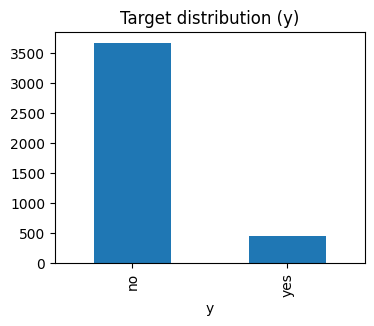


Explicit missing (NaN) summary (top):
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

Implicit missing as 'unknown' (top):
           unknown_count  unknown_pct
default              803        19.50
education            167         4.05
housing              105         2.55
loan                 105         2.55
job                   39         0.95
marital               11         0.27

Implicit missing sentinel in pdays (999): 3959 (96.12%)


In [5]:
#target distribution and potential class imbalance

#this following code block was generated by [ChatGPT 5.2 Thinking].
#The prompts used include [Please help me how to detect explicit and implicit
# missing values and fix any syntax errors I might have.]

print("\nTarget distribution (counts):")
print(df["y"].value_counts())
print("\nTarget distribution (proportions):")
print(df["y"].value_counts(normalize=True))

fig, ax = plt.subplots(figsize=(4,3))
df["y"].value_counts().plot(kind="bar", ax=ax)
plt.title("Target distribution (y)")
plt.show()

# explicit missing (NaN)
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
print("\nExplicit missing (NaN) summary (top):")
print(missing_table[missing_table["missing_count"] > 0].head(20))

# implicit missing: 'unknown' in categorical
unknown_counts = {}
for c in cat_cols:
    unknown_counts[c] = (df[c].astype(str).str.strip().str.lower() == "unknown").sum()
unknown_table = (pd.DataFrame({"unknown_count": unknown_counts})
                   .sort_values("unknown_count", ascending=False))
unknown_table["unknown_pct"] = (unknown_table["unknown_count"] / len(df) * 100).round(2)
print("\nImplicit missing as 'unknown' (top):")
print(unknown_table[unknown_table["unknown_count"] > 0].head(20))

# implicit missing: sentinel u pdays

if "pdays" in df.columns:
    sentinel_999 = (df["pdays"] == 999).sum()
    print(f"\nImplicit missing sentinel in pdays (999): {sentinel_999} ({sentinel_999/len(df)*100:.2f}%)")

#NOTE on AI Use in this step: Parts of the code here were generated/fixed by AI,
#as indicated by the inital comment before! The entirety of the code was not.


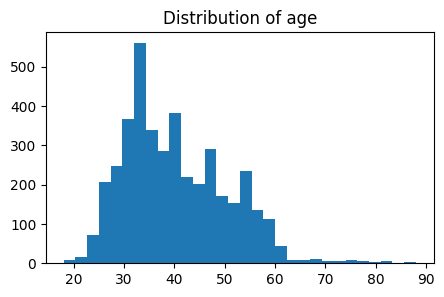

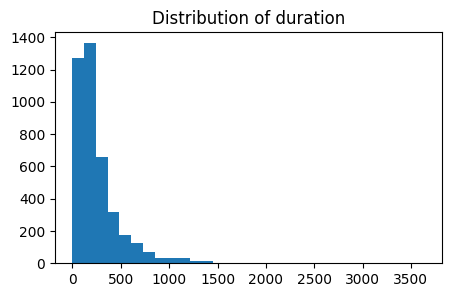

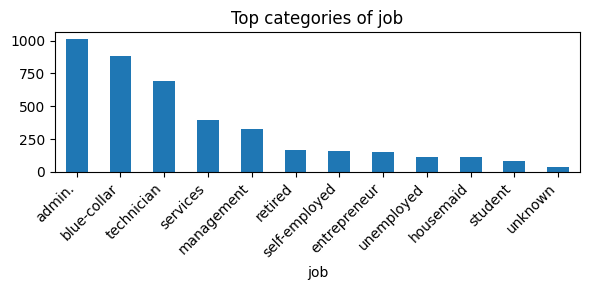

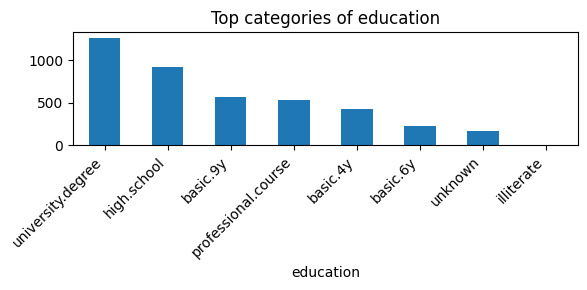


Variables requiring special consideration:
- duration (available only after the call ends, risk of data leakage)
- pdays often uses sentinel value 999 (not previously contacted): needs indicator handling


In [6]:
#visualization 2 numerical variables (like age and duration)
#this following code block was generated by [ChatGPT 5.2 Thinking].
# The prompts used include [Help me to generate the graphs of 2 categorical
# variables and how do I find special considerations in the dataset?]

num_to_plot = [c for c in ["age", "duration"] if c in df.columns]
if len(num_to_plot) < 2 and len(num_cols) >= 2:
    num_to_plot = num_cols[:2]

for c in num_to_plot[:2]:
    fig, ax = plt.subplots(figsize=(5,3))
    ax.hist(df[c].dropna(), bins=30)
    ax.set_title(f"Distribution of {c}")
    plt.show()

#visualization of 2 categorical variables (job and education)

cat_to_plot = [c for c in ["job", "education"] if c in df.columns]
if len(cat_to_plot) < 2 and len(cat_cols) >= 2:
    cat_to_plot = cat_cols[:2]

for c in cat_to_plot[:2]:
    fig, ax = plt.subplots(figsize=(6,3))
    df[c].value_counts().head(15).plot(kind="bar", ax=ax)
    ax.set_title(f"Top categories of {c}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

#special consideration
special_notes = []
if "duration" in df.columns:
    special_notes.append("duration (available only after the call ends, risk of data leakage)")
if "pdays" in df.columns:
    special_notes.append("pdays often uses sentinel value 999 (not previously contacted): needs indicator handling")

print("\nVariables requiring special consideration:")
for s in special_notes[:2]:
    print("-", s)

#Comments for this step:
There is a clear class imbalance issue with y, the target variable, accuracy can be therefore a bit off. We need to keep an eye out for the precision/recall scores. Specifically, the distribution of the target is 89/11, which confirms the imbalance issue.

There are almost none explicit NaN values, but there is an implicit missingness, as several categorical variables have the value 'unknown', and the pdays uses the default sentinel 999 for about 96% of the rows, so those values have to be treated specially.

When it comes to the special considerations, the duration variable is prone to leakage, because at the time of predicting, its value is not known.



# 4. Managing Missing Values

In [7]:
#now let's identify/handle any missing values we might have
df.isnull().sum()
missing_na = X.isna().sum().sort_values(ascending=False)
missing_na_pct = (X.isna().mean()*100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_na,
    "missing_pct": missing_na_pct
}).query("missing_count > 0")

missing_summary

#this following code block was generated by [ChatGPT 5.2 Thinking].
# The prompts used include [Help me fix the code for getting the implicit
# missing data for categorical variables with the 'missing' tokens and
#, also for the numerical ones. Create a final profile with the most common
#values and summarize the extent of the missingness.]

#implicit missing (categorical)
unknown_tokens = {"unknown","unk","n/a","na","none","null","?",
                  "missing","not provided","other/unknown"}

cat_cols = X.select_dtypes(include=["object","category","bool"]).columns

implicit_cat = {}
for c in cat_cols:
    s = X[c].astype(str).str.strip().str.lower()
    mask = s.isin(unknown_tokens)
    if mask.any():
        implicit_cat[c] = {
            "count": int(mask.sum()),
            "pct": float(mask.mean()*100)
        }

implicit_cat

#numerical implicit
num_cols = X.select_dtypes(include=["int64","float64"]).columns

# fast profile
profile = X[num_cols].describe(percentiles=[.01,.05,.95,.99]).T

# most common values
top_values = {c: X[c].value_counts(dropna=False).head(5) for c in num_cols}

profile.head(), list(top_values.items())[:2]

sentinels = [-1, -9, 99, 999]

implicit_num = {}
for c in num_cols:
    mask = X[c].isin(sentinels)
    if mask.any():
        implicit_num[c] = {
            "count": int(mask.sum()),
            "pct": float(mask.mean()*100),
            "unique_sentinels_found": sorted(X.loc[mask, c].unique().tolist())
        }

implicit_num

#extent of missingness
X_clean = X.copy()

for c in cat_cols:
    s = X_clean[c].astype(str).str.strip().str.lower()
    X_clean.loc[s.isin(unknown_tokens), c] = np.nan

for c in num_cols:
    X_clean.loc[X_clean[c].isin(sentinels), c] = np.nan

#calculate missingness again

missing_total = X_clean.isna().sum().sort_values(ascending=False)
missing_total_pct = (X_clean.isna().mean()*100).sort_values(ascending=False)

missing_total_summary = pd.DataFrame({
    "missing_count_total": missing_total,
    "missing_pct_total": missing_total_pct
}).query("missing_count_total > 0")

missing_total_summary

,missing_count_total,missing_pct_total
pdays,3959,96.115562
default,803,19.495023
education,167,4.054382
loan,105,2.549162
housing,105,2.549162
job,39,0.946832
duration,14,0.339888
marital,11,0.267055


In [8]:
#now, let's see how I should handle the missingness

X2 = X.copy()

# pdays: indicator and sentinel to NaN
X2["prev_contact"] = (X2["pdays"] != 999).astype(int) #999 was the default value
#when it was missing, the sentinel.
X2["pdays"] = X2["pdays"].replace(999, np.nan)

# categorical variables: treat 'unknown' as missing (later "Unknown", imputer)
cat_vars = ["default", "education", "loan", "housing", "job", "marital"]
for c in cat_vars:
    X2[c] = X2[c].astype(str).str.strip()
    X2.loc[X2[c].str.lower() == "unknown", c] = np.nan

# duration, leave as numeric NaN
# median, impute it

In [9]:
#which operations must be fitted using the training set only, and explain why:

# 1) split
#this following code block was generated by [ChatGPT 5.2 Thinking].
# The prompts used include [How do I create the pipes for preprocessing,
#to create the inital train/test split?]
X_train, X_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)

# 2) preprocessing (fit only on train via pipeline)
num_cols = X_train.select_dtypes(include=["int64","float64"]).columns
cat_cols = X_train.select_dtypes(include=["object","category","bool"]).columns

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

model = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'prev_contact'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object'))])),
                ('clf', LogisticRegression(max_iter=1000))])

#Comments for this part:
"When it comes to explicit and implicit missingness, the data has almost no explicit NaN values, but it does have more implicit. In categorical variables especially, the category 'unknown' serves as a placeholder for missing values. For numerical variables, the default value is 999, which is not an actual accurate measurement but rather a special code for "not previously contacted".

After mapping these implicit codes to NaN, we quantified missingness per feature (missing counts & percentages), confirming that pdays has very high implicit missingness and several categorical features have non-trivial rates of “unknown”. Not something to ignore.

How to handle this?

For pdays, we replace 999 with NaN and create an indicator prev_contact = 1(pdays != 999) so the model can capture the informative signal of prior contact while not treating 999 as a numeric value.

For categorical variables with “unknown”, we map “unknown” to NaN and then impute a separate category “Unknown” instead of  dropping rows, because missingness itself may be predictive of something else.

For remaining numerical variables, we use median imputation to be robust to skewness/outliers.

Mapping implicit placeholders (“unknown”, 999) to NaN is a data cleaning step to correct inconsistent encodings of missingness. Adding prev_contact and choosing specific imputers,median / “Unknown”, are modeling decisions because they determine how missingness is represented to the model and allow missingness to carry predictive information.

For train-only fitting, imputation, scaling, and encoding must be fitted on the training set only: imputer statistics, scaler mean/standard dev, and encoder category mappings.

Fitting these steps on the full dataset would leak validation/test distributional information into training and lead to overly optimistic evaluation."

NOTE on AI Use for this comment section: The original text was written by me,
only refined by AI for treating unclear comments.

This text was generated by [ChatGPT 5.2 Thinking]. The prompts used include [Please refine this text and make the comments completely clear.]

# 5. Feature Selection

In [10]:
Xtr = X_train.copy()

# take only numerical columns
num_cols = Xtr.select_dtypes(include=["int64","float64"]).columns

# minimal imputation (train-only)
Xtr_num = Xtr[num_cols].copy()
Xtr_num = Xtr_num.fillna(Xtr_num.median(numeric_only=True))

vt = VarianceThreshold(threshold=1e-4)
vt.fit(Xtr_num)

low_var_num = num_cols[~vt.get_support()].tolist()
low_var_num

#highlight the highly correlated variables

corr = Xtr_num.corr(numeric_only=True).abs()

#this following code block was generated by [ChatGPT 5.2 Thinking].
# The prompts used include [How do I avoid duplicates in feature selection in
#code and how to determine what to drop in logistic regression?]

# take the upper triangle, to avoid duplicates

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

threshold = 0.90
high_corr_pairs = (
    upper.stack()
    .sort_values(ascending=False)
    .loc[lambda s: s >= threshold]
)

high_corr_pairs.head(20)

# if y_train is y/n
ytr_num = y_train.map({"no":0, "yes":1}) if y_train.dtype == "object" else y_train

target_corr = Xtr_num.assign(y=ytr_num).corr(numeric_only=True)["y"].abs().drop("y")

to_drop_corr = set()
for (a, b), val in high_corr_pairs.items():
    # drop those with less connection to the target
    drop = a if target_corr.get(a, 0) < target_corr.get(b, 0) else b
    to_drop_corr.add(drop)

sorted(to_drop_corr)

#list the features to drop

features_to_drop = set(low_var_num) | set(to_drop_corr) | {"duration"}  # duration if it is conceptually dropped

X_train_fs = X_train.drop(columns=[c for c in features_to_drop if c in X_train.columns])
X_test_fs  = X_test.drop(columns=[c for c in features_to_drop if c in X_test.columns])

#Comments for this part:
"Low variance issue:
I removed numerical features with very low variance using VarianceThreshold(threshold=1e-4). A near-zero variance feature carries almost no information. For Logistic Regression, such features add noise and can worsen numerical conditioning without improving predictive power. The threshold 1e-4 was chosen as a conservative ‘near-constant’ cutoff after scaling-independent inspection: values essentially constant in raw units.

High correlation: I examined pairwise absolute correlations among numerical features and flagged pairs with r>= 0.90. This threshold indicates very strong linear dependence, keeping both features is largely redundant. In Logistic Regression, strong multicollinearity makes coefficients unstable: small data changes can turn around coefficient magnitudes/signs, reduce interpretability, and can harm generalization. For each highly correlated pair, we dropped the feature with the weaker absolute correlation with the target  to preserve the more informative signal.

Removal: Duration, for conceptual reasons: it is only known after the call ends, so using it would cause data leakage and make evaluation unrealistically optimistic. Since our goal is to predict subscription at decision time, duration is not available at prediction time and must be excluded for this purpose.”

Why train only?

Feature selection must be performed using the training set only because selection uses information from the data distribution, and, in our case, also the target association when choosing which correlated feature to drop. If the full dataset is used, information from validation/test leaks into feature selection, resulting in overly optimistic validation/test metrics and a larger estimate of generalization.

What happens if I do the selection before splitting?

The test set influences which features are kept (especially through correlation structure and target correlations). This ‘peeking’ reduces the apparent difficulty of the test set and produces biased evaluation. The model may not perform as well on truly unseen data where the correlation structure differs, lowering its quality."

This text was generated by [ChatGPT 5.2 Thinking]. The prompts used include [Please tell me how to interpret the (outputs of code-feature selection)?]
NOTE: again, the original comments were written by me, the final version is just refined by AI.

# 6. Encoding Categorical Variables

In [11]:
cat_cols = X.select_dtypes(include=["object","category","bool"]).columns.tolist()
cat_cols
#nominal variables are those that have no importance in order:
# job, marital, default, housing, loan, contact, month, day_of_week, poutcome
# for these we can use one hot encoding

#education (level) is the only logical variable that has importance in
# order or highness in education


#now that the variables are recognized, it's time to encode them

Xtr = X_train_fs.copy()
Xte = X_test_fs.copy()

#this following code block was generated by [ChatGPT 5.2 Thinking].
# The prompts used include [How do I encode categorical variables here, along
#with the necessary pipes?]

# define the columns
ordinal_col = ["education"]
nominal_cols = [c for c in cat_cols if c not in ordinal_col]

num_cols = Xtr.select_dtypes(include=["int64","float64"]).columns.tolist()

# gradation of levels of education
education_order = [
    "illiterate",
    "basic.4y",
    "basic.6y",
    "basic.9y",
    "high.school",
    "professional.course",
    "university.degree",
    "Unknown"   # for imputation
]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

nominal_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

ordinal_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("ord", OrdinalEncoder(categories=[education_order]))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("nom", nominal_pipe, nominal_cols),
        ("ord", ordinal_pipe, ordinal_col),
    ],
    remainder="drop"
)

# fit onto the train set
preprocess.fit(Xtr)

# transform train/test
Xtr_enc = preprocess.transform(Xtr)
Xte_enc = preprocess.transform(Xte)

Xtr.shape, Xtr_enc.shape

#dimensionality before and after


((3295, 18), (3295, 45))

#Comments for this part:
"Train-only fitting. Both OneHotEncoder and OrdinalEncoder must be fitted on the training set only because they learn mappings from categories to columns/codes. Fitting them on the full dataset would leak information about categories present only in validation/test, leading to overly optimistic evaluation and a pipeline that is not faithful to deployment conditions.

Dimensionality change. Encoding increases the number of features because One-Hot expands each nominal variable into multiple binary indicator columns. In our case, the feature space changes from Xtr.shape[1] raw features to Xtr_enc.shape[1] encoded features (as shown by the before/after shapes). Ordinal encoding for education adds only one column, while One-Hot can add many columns depending on the number of categories.

Interpretability of coefficients. After One-Hot encoding (with drop="first"), each coefficient corresponds to the change in log-odds of subscribing when that category is present relative to the dropped baseline category, holding other features constant. For education encoded ordinally, the coefficient represents the change in log-odds for a one-level increase in education rank (under the monotonic linear assumption). This makes coefficient interpretation straightforward but also highlights that ordinal encoding imposes a structured assumption.

Decision boundaries and expressiveness. Logistic Regression can only learn linear decision boundaries in the encoded feature space. One-Hot encoding allows the model to assign different offsets to different categories, effectively creating piecewise shifts in the decision boundary across categories. However, it cannot represent interactions between categories (e.g., job × month) unless interaction features are explicitly engineered. Ordinal encoding constrains education to influence the boundary in a monotonic linear way, which can improve stability and reduce dimensionality, but may underfit if the true relationship is non-monotonic."

This text was generated by [ChatGPT 5.2 Thinking]. The prompts used include [How do I comment on the change of dimensioality due to the change in features and how do I interpret the outputted metrics in short?]

#  7. Data Splitting

In [12]:
# X2 = cleaned features after
# y  = target

# 1)first the test set (15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X2, y, test_size=0.15, random_state=42, stratify=y
)

# 2) from the rest make the validation (15% total => 15/85 = 0.17647 of trainval)
val_size = 0.15 / 0.85

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_size, random_state=42, stratify=y_trainval
)

print("Train:", X_train.shape, y_train.value_counts(normalize=True))
print("Val:",   X_val.shape,   y_val.value_counts(normalize=True))
print("Test:",  X_test.shape,  y_test.value_counts(normalize=True))

Train: (2883, 21) y
no     0.890739
yes    0.109261
Name: proportion, dtype: float64
Val: (618, 21) y
no     0.889968
yes    0.110032
Name: proportion, dtype: float64
Test: (618, 21) y
no     0.889968
yes    0.110032
Name: proportion, dtype: float64


#Comments for this part:
We used a 70/15/15 split. The training set is kept largest to estimate stable model parameters, the validation set is used for model selection / threshold decisions, and the test set is held out for a final unbiased evaluation.

Stratification is necessary because the target is imbalanced (~89% ‘no’ vs 11% ‘yes’). Without stratification, random splitting could produce validation/test sets with very few positive examples, making precision/recall unstable and evaluation unreliable.

The split must occur before any preprocessing steps that learn parameters from the data (imputation, encoding, scaling, feature selection, and resampling). If splitting were performed later, statistics such as medians (imputer), means/standard deviations (scaler), or category mappings (encoder) would be computed using validation/test information, causing data leakage and overly optimistic performance estimates.

This text was generated by [ChatGPT 5.2 Thinking]. The prompts used include [What can you tell me about the outputs I got for the splitting and based when it occured in the pipeline?]

# 8. Feature Scaling

In [13]:
X_train_fs = X_train.drop(columns=[c for c in features_to_drop if c in X_train.columns])
X_val_fs   = X_val.drop(columns=[c for c in features_to_drop if c in X_val.columns])
X_test_fs  = X_test.drop(columns=[c for c in features_to_drop if c in X_test.columns])

num_cols = X_train_fs.select_dtypes(include=["int64","float64"]).columns.tolist()
binary_num = [c for c in num_cols if set(X_train_fs[c].dropna().unique()).issubset({0,1})]
cont_num = [c for c in num_cols if c not in binary_num]

print("Binary numeric:", binary_num)
print("Continuous numeric:", cont_num)

scaler = StandardScaler()
X_train_scaled_num = scaler.fit_transform(X_train_fs[cont_num])  # fit on train
X_val_scaled_num   = scaler.transform(X_val_fs[cont_num])        # transform val
X_test_scaled_num  = scaler.transform(X_test_fs[cont_num]) # transform test

Binary numeric: ['prev_contact']
Continuous numeric: ['age', 'campaign', 'pdays', 'previous', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']


#Comments for this part:

We identified numerical variables and scaled the continuous ones (cont_num). Binary numeric indicators (0/1) were not scaled because they are already on a comparable scale. These are the ones that need scaling.

We used standardization (StandardScaler), i.e., centering features to mean 0 and scaling to standard deviation 1. This is appropriate for Logistic Regression because the model is trained via gradient-based optimization and is sensitive to feature scale.

"The following transformations must be fitted using the training set only:
StandardScaler (learns the mean and standard deviation of each numerical feature),
SimpleImputer(strategy="median") (learns the median used to fill missing values)

They must be train-only because these steps learn parameters from the data distribution. If they were fitted on the full dataset (train+validation+test), the validation/test distributions would influence the learned statistics (mean/std/median/categories), causing data leakage and making evaluation metrics artificially optimistic.

Feature effects:
Without scaling, features with large numeric ranges dominate the gradient, leading to poorly conditioned optimization and slow/unstable convergence. Standardization makes feature scales comparable, improving conditioning and usually resulting in faster and more stable convergence.


Without scaling, coefficient magnitudes are not directly comparable because a “1-unit change” in different features can represent very different real-world changes. After standardization, a coefficient approximately reflects the change in log-odds for a one standard deviation increase in that feature, making coefficient magnitudes more comparable across numerical variables."

This text was generated by [ChatGPT 5.2 Thinking]. The prompts used include [Why are the transformations train-only and what are the final causes of that on the features)?]

Regularization (L1/L2) penalizes coefficient magnitudes. If features are not scaled, the penalty effectively treats features unequally because features with larger scales can achieve the same effect with smaller coefficients (or vice versa). Scaling makes regularization fairer and more interpretable, because coefficients correspond to changes on a comparable feature scale.

# 9. Addressisng Class Imbalance


In [14]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X2, y, test_size=0.15, random_state=42, stratify=y
)

val_size = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_size, random_state=42, stratify=y_trainval
)

assert X_train.shape[0] == y_train.shape[0]
assert X_val.shape[0]   == y_val.shape[0]
assert X_test.shape[0]  == y_test.shape[0]

X_train_fs = X_train.drop(columns=[c for c in features_to_drop if c in X_train.columns])
X_val_fs   = X_val.drop(columns=[c for c in features_to_drop if c in X_val.columns])
X_test_fs  = X_test.drop(columns=[c for c in features_to_drop if c in X_test.columns])

assert X_train_fs.shape[0] == y_train.shape[0]
assert X_val_fs.shape[0]   == y_val.shape[0]
assert X_test_fs.shape[0]  == y_test.shape[0]

print("Train distribution (counts):")
print(y_train.value_counts())
print("\nTrain distribution (proportions):")
print(y_train.value_counts(normalize=True))

#this following code block was generated by [ChatGPT 5.2 Thinking].
# The prompts used include [What type of solution should I use to address the
#class imbalance?, since the ]

imb_model = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("over", RandomOverSampler(random_state=42)),
    ("clf", LogisticRegression(max_iter=1000))
])

imb_model.fit(X_train_fs, y_train)

val_pred  = imb_model.predict(X_val_fs)
test_pred = imb_model.predict(X_test_fs)

ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_fs, y_train)

print("\nBefore resampling:")
print(y_train.value_counts())
print("\nAfter resampling:")
print(y_train_res.value_counts())

Train distribution (counts):
y
no     2568
yes     315
Name: count, dtype: int64

Train distribution (proportions):
y
no     0.890739
yes    0.109261
Name: proportion, dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



Before resampling:
y
no     2568
yes     315
Name: count, dtype: int64

After resampling:
y
no     2568
yes    2568
Name: count, dtype: int64


#Comments for this part:

The target is clearly imbalanced in the training set: majority class ‘no’ dominates, minority class ‘yes’ is much smaller. This is a concern because a model can achieve high accuracy by predicting the majority class, while failing to identify the minority class which is generally relevant in a business context.

I applied Random Over-Sampling on the training set only using RandomOverSampler. The resampling step is placed inside the training pipeline, after preprocessing (imputation, scaling etc.) and before fitting the logistic regression model. This ensures that only the training data are resampled and that validation/test sets preserve the original class distribution.

This text was generated by [ChatGPT 5.2 Thinking]. The prompts used include [Why would I use random oversampling in this case?]

"Random oversampling makes no strong geometric assumptions about the feature space; it simply replicates minority-class examples. This is a safe choice when the dataset includes many one-hot encoded categorical features, where interpolation-based methods like SMOTE can generate unrealistic “fractional” category combinations. The expected effect is reduced bias toward the majority class and improved minority-class recall, often at the cost of more false positives.

If resampling were applied before splitting, duplicated samples (or synthetic samples, in SMOTE-like methods) could appear in both training and validation/test sets. This would cause severe data leakage, inflating evaluation metrics because the model effectively sees near-identical examples during training and evaluation. The resulting validation/test performance would be overly optimistic and not representative of real-world generalization.

With class imbalance, accuracy can be misleading because predicting the majority class yields a high score even when the model fails on the minority class. Recall for the minority class is often low without corrective measures (many positives missed), while precision can drop when the model starts predicting more positives. Therefore, precision/recall and often F1/AUC provide a more informative evaluation than accuracy alone."

# 10. Training a Logistic Regression Model

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Validation Accuracy : 0.9029
Validation Precision: 0.6667
Validation Recall   : 0.2353
Zero Rule majority class: no
Zero Rule Accuracy (val): 0.8900
LR Accuracy (val)       : 0.9029
Accuracy improvement    : 0.0129


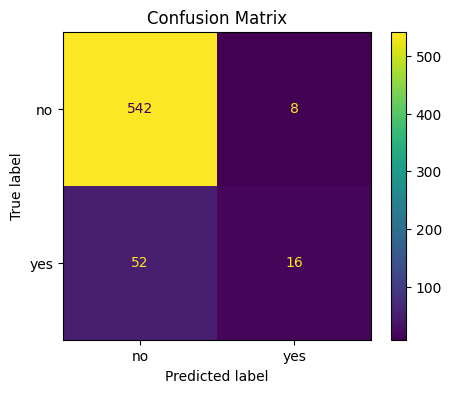

In [15]:
#this following code block was generated by [ChatGPT 5.2 Thinking].
# The prompts used include [How do I train the model with the split and
# to generate predictions that are as accurate as possible, based on
#previous findings, with a confusion matrix and zero baseline comparison at the
#end?]


X_trainval, X_test, y_trainval, y_test = train_test_split(
    X2, y, test_size=0.15, random_state=42, stratify=y
)
val_size = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_size, random_state=42, stratify=y_trainval
)

# sanity
assert X_train.shape[0] == y_train.shape[0]
assert X_val.shape[0]   == y_val.shape[0]
assert X_test.shape[0]  == y_test.shape[0]

#  feature selection
#    low variance + high correlation + drop duration
Xtr = X_train.copy()
num_cols = Xtr.select_dtypes(include=["int64","float64"]).columns

# minimal imputation (train-only) just for variance/corr computations
Xtr_num = Xtr[num_cols].copy().fillna(Xtr[num_cols].median(numeric_only=True))

# low variance
vt = VarianceThreshold(threshold=1e-4)
vt.fit(Xtr_num)
low_var_num = num_cols[~vt.get_support()].tolist()

# high correlation
corr = Xtr_num.corr(numeric_only=True).abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
threshold = 0.90
high_corr_pairs = (
    upper.stack()
    .sort_values(ascending=False)
    .loc[lambda s: s >= threshold]
)

# choose which to drop based on weaker association with target (train-only)
ytr_num = y_train.map({"no":0, "yes":1}) if y_train.dtype == "object" else y_train
target_corr = Xtr_num.assign(y=ytr_num).corr(numeric_only=True)["y"].abs().drop("y")

to_drop_corr = set()
for (a, b), _ in high_corr_pairs.items():
    drop = a if target_corr.get(a, 0) < target_corr.get(b, 0) else b
    to_drop_corr.add(drop)

features_to_drop = set(low_var_num) | set(to_drop_corr)
if "duration" in X_train.columns:
    features_to_drop |= {"duration"}   # conceptual leakage drop

# apply same drops to train/val/test
X_train_fs = X_train.drop(columns=[c for c in features_to_drop if c in X_train.columns])
X_val_fs   = X_val.drop(columns=[c for c in features_to_drop if c in X_val.columns])
X_test_fs  = X_test.drop(columns=[c for c in features_to_drop if c in X_test.columns])

# sanity again
assert X_train_fs.shape[0] == y_train.shape[0]
assert X_val_fs.shape[0]   == y_val.shape[0]
assert X_test_fs.shape[0]  == y_test.shape[0]


#  train LR + evaluation on validation

lr_model = Pipeline(steps=[
    ("preprocess", preprocess),                 # my ColumnTransformer (impute+encode+scale)
    ("clf", LogisticRegression(max_iter=1000))
])

lr_model.fit(X_train_fs, y_train)
y_val_pred = lr_model.predict(X_val_fs)

acc  = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, pos_label="yes") if y_val.dtype == "object" else precision_score(y_val, y_val_pred)
rec  = recall_score(y_val, y_val_pred, pos_label="yes")    if y_val.dtype == "object" else recall_score(y_val, y_val_pred)

print(f"Validation Accuracy : {acc:.4f}")
print(f"Validation Precision: {prec:.4f}")
print(f"Validation Recall   : {rec:.4f}")

# zero rule baseline
majority_class = y_train.value_counts().idxmax()
y_val_pred_zero = np.full(len(y_val), majority_class)
acc_zero = accuracy_score(y_val, y_val_pred_zero)

print("Zero Rule majority class:", majority_class)
print(f"Zero Rule Accuracy (val): {acc_zero:.4f}")
print(f"LR Accuracy (val)       : {acc:.4f}")
print(f"Accuracy improvement    : {acc - acc_zero:.4f}")

# confusion matrix
labels = ["no","yes"] if y_val.dtype == "object" else [0,1]
cm = confusion_matrix(y_val, y_val_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix")
plt.show()

#Comments for this part & Final Comments (End of Notebook):

Overall, the model behaves sensibly. It slightly outperforms the Zero Rule baseline and achieves high accuracy, but recall on the minority ‘yes’ class is low, suggesting that class imbalance handling (resampling or class weights) or threshold tuning could be needed if the business goal is to capture more potential subscribers.